loading the dataset for understanding and visualization 

In [2]:
from pathlib import Path
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import lasio

# Project root
PROJECT_ROOT = Path.cwd().parent

# Dataset location
DATA_DIR = PROJECT_ROOT / "data" / "raw" / "FORCE_2020"

print("Project root :", PROJECT_ROOT)
print("Data folder  :", DATA_DIR)
print("Data exists  :", DATA_DIR.exists())

Project root : /Users/akashray/Lithology_Predictor
Data folder  : /Users/akashray/Lithology_Predictor/data/raw/FORCE_2020
Data exists  : True


finding the number of wells


In [3]:
las_files = sorted(DATA_DIR.glob("*.las"))

print(f"Number of LAS files found: {len(las_files)}")

print("\nFirst 10 files:")
for path in las_files[:10]:
    print(path.name)

Number of LAS files found: 118

First 10 files:
15_9-13.las
15_9-14.las
15_9-15.las
15_9-17.las
15_9-23.las
16_1-2.las
16_1-6 A.las
16_10-1.las
16_10-2.las
16_10-3.las


inspecting the first well

In [4]:
first_las_path = las_files[0]

las = lasio.read(first_las_path)

print("File:", first_las_path.name)
print(las)

File: 15_9-13.las


In [4]:
print("Number of curves:", len(las.curves))

print("\nCurves:")
for curve in las.curves:
    print(curve.mnemonic, "-", curve.unit, "-", curve.descr)

Number of curves: 21

Curves:
DEPT - m - DEPTH
FORCE_2020_LITHOFACIES_CONFIDENCE - _ - FORCE_2020_LITHOFACIES_CONFIDENCE
FORCE_2020_LITHOFACIES_LITHOLOGY - _ - FORCE_2020_LITHOFACIES_LITHOLOGY
CALI - in - CALI
MUDWEIGHT - _ - MUDWEIGHT
ROP - m/h - ROP
RDEP - ohm.m - RDEP
RSHA - ohm.m - RSHA
RMED - ohm.m - RMED
RXO - ohm.m - RXO
SP - mV - SP
DTC - us/ft - DTC
NPHI - m3/m3 - NPHI
PEF - b/e - PEF
GR - gAPI - GR
RHOB - g/cm3 - RHOB
DRHO - g/cm3 - DRHO
DEPTH_MD - _ - DEPTH_MD
X_LOC - _ - x_loc
Y_LOC - _ - y_loc
Z_LOC - _ - z_loc


In [15]:
las.well.STEP.value

np.float64(0.152)

Convert one LAS to a DataFrame and saving 

In [21]:
df = las.df().reset_index()

df

,DEPT,FORCE_2020_LITHOFACIES_CONFIDENCE,FORCE_2020_LITHOFACIES_LITHOLOGY,CALI,MUDWEIGHT,ROP,RDEP,RSHA,RMED,RXO,...,DTC,NPHI,PEF,GR,RHOB,DRHO,DEPTH_MD,X_LOC,Y_LOC,Z_LOC
0,25.000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,206.224609,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,25.152,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,206.224625,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,25.304,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,206.224655,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,25.456,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,206.224670,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,25.608,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,206.224701,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21436,3283.272,NaN,NaN,NaN,NaN,NaN,8.0,NaN,7.9922,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,3283.271973,437593.0,6470982.5,-3257.389893
21437,3283.424,NaN,NaN,NaN,NaN,NaN,8.0,NaN,7.9922,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,3283.424072,437593.0,6470982.5,-3257.541992
21438,3283.576,NaN,NaN,NaN,NaN,NaN,8.0,NaN,7.9922,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,3283.575928,437593.0,6470982.5,-3257.693848
21439,3283.728,NaN,NaN,NaN,NaN,NaN,8.0,NaN,7.9922,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,3283.728027,437593.0,6470982.5,-3257.845703


so in total there are 21441 rows in this first well with 21 columns


In [ ]:

# output_folder = "./visualization_result"
# output_file = "well_1.csv"

# os.makedirs(output_folder, exist_ok=True)

# full_path = os.path.join(output_folder, output_file)
# df.to_csv(full_path, index=False)

# print(f"Saved successfully to: {full_path}")

Saved successfully to: ./visualization_result/well_1.csv


inspecting the logs and the total null values associated  inthe first well so one can get the overall idea that how we should deal with this dataset due to the inconsistency in the data

In [36]:
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())


Shape: (21441, 21)

Columns:
['DEPT', 'FORCE_2020_LITHOFACIES_CONFIDENCE', 'FORCE_2020_LITHOFACIES_LITHOLOGY', 'CALI', 'MUDWEIGHT', 'ROP', 'RDEP', 'RSHA', 'RMED', 'RXO', 'SP', 'DTC', 'NPHI', 'PEF', 'GR', 'RHOB', 'DRHO', 'DEPTH_MD', 'X_LOC', 'Y_LOC', 'Z_LOC']


In [41]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 21441 entries, 0 to 21440
Data columns (total 21 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   DEPT                               21441 non-null  float64
 1   FORCE_2020_LITHOFACIES_CONFIDENCE  18277 non-null  float64
 2   FORCE_2020_LITHOFACIES_LITHOLOGY   18270 non-null  float64
 3   CALI                               18345 non-null  float64
 4   MUDWEIGHT                          17520 non-null  float64
 5   ROP                                20297 non-null  float64
 6   RDEP                               20956 non-null  float64
 7   RSHA                               1623 non-null   float64
 8   RMED                               20957 non-null  float64
 9   RXO                                1627 non-null   float64
 10  SP                                 20956 non-null  float64
 11  DTC                                21282 non-null  float64
 12  N

In [42]:
for col in df.columns:
    print(f"{col  }:{df[col].dtype},    noNan count: {df[col].notnull().sum()},       NaN count: {df[col].isna().sum()},       percent NaN: {df[col].isna().mean() * 100:.2f}%")

DEPT:float64,    noNan count: 21441,       NaN count: 0,       percent NaN: 0.00%
FORCE_2020_LITHOFACIES_CONFIDENCE:float64,    noNan count: 18277,       NaN count: 3164,       percent NaN: 14.76%
FORCE_2020_LITHOFACIES_LITHOLOGY:float64,    noNan count: 18270,       NaN count: 3171,       percent NaN: 14.79%
CALI:float64,    noNan count: 18345,       NaN count: 3096,       percent NaN: 14.44%
MUDWEIGHT:float64,    noNan count: 17520,       NaN count: 3921,       percent NaN: 18.29%
ROP:float64,    noNan count: 20297,       NaN count: 1144,       percent NaN: 5.34%
RDEP:float64,    noNan count: 20956,       NaN count: 485,       percent NaN: 2.26%
RSHA:float64,    noNan count: 1623,       NaN count: 19818,       percent NaN: 92.43%
RMED:float64,    noNan count: 20957,       NaN count: 484,       percent NaN: 2.26%
RXO:float64,    noNan count: 1627,       NaN count: 19814,       percent NaN: 92.41%
SP:float64,    noNan count: 20956,       NaN count: 485,       percent NaN: 2.26%
DTC:flo

now we will the basic statistic performed on this well and theie results

In [44]:
df.describe()

,DEPT,FORCE_2020_LITHOFACIES_CONFIDENCE,FORCE_2020_LITHOFACIES_LITHOLOGY,CALI,MUDWEIGHT,ROP,RDEP,RSHA,RMED,RXO,...,DTC,NPHI,PEF,GR,RHOB,DRHO,DEPTH_MD,X_LOC,Y_LOC,Z_LOC
count,21441.00000,18277.000000,18270.000000,18345.000000,17520.000000,20297.000000,20956.000000,1623.000000,20957.000000,1627.000000,...,21282.000000,14105.000000,16446.000000,20900.000000,18345.000000,18345.000000,20956.000000,20956.000000,2.095600e+04,20956.000000
mean,1654.44000,1.039394,60476.696223,14.766734,0.139824,28.554482,1.934587,2.901504,1.777486,5.748493,...,132.228668,0.403497,3.467550,63.127582,2.113472,0.012935,1691.300000,437628.925584,6.470978e+06,-1666.082887
std,940.82344,0.277921,13972.748152,4.386417,0.009479,30.589891,2.759186,3.474120,2.739401,71.588789,...,33.646244,0.134053,2.576539,28.701134,0.301098,0.048039,919.542309,14.342905,3.677640e+00,919.344110
min,25.00000,1.000000,30000.000000,8.186605,0.129413,0.138586,0.352202,0.175400,0.116862,0.171424,...,55.726753,0.024330,1.010027,6.191506,1.404576,-0.679026,98.720001,437592.906250,6.470972e+06,-3257.997803
25%,839.72000,1.000000,65000.000000,12.101601,0.133007,5.249922,0.830621,0.934778,0.780284,0.934500,...,95.920670,0.314235,2.320927,41.265792,1.964058,-0.007177,895.009979,437616.375000,6.470975e+06,-2462.194214
50%,1654.44000,1.000000,65000.000000,13.896447,0.136602,31.011793,1.386364,1.473143,1.230179,1.455721,...,144.200439,0.447975,2.790998,66.990936,2.055773,0.001629,1691.299988,437636.234375,6.470978e+06,-1666.196960
75%,2469.16000,1.000000,65000.000000,18.301279,0.144990,40.664753,2.047000,3.352066,1.972084,3.464941,...,153.726254,0.506147,4.268998,82.098042,2.388569,0.020609,2487.590027,437640.937500,6.470982e+06,-869.973602
max,3283.88000,3.000000,99000.000000,23.329569,0.156973,1083.425415,168.014252,54.536583,142.606338,2000.000000,...,206.225693,0.800262,66.030319,499.022583,2.938594,0.210927,3283.879883,437642.812500,6.470984e+06,-73.719467


In [45]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
DEPT,21441.0,1.654440e+03,940.823440,2.500000e+01,8.397200e+02,1.654440e+03,2.469160e+03,3.283880e+03
FORCE_2020_LITHOFACIES_CONFIDENCE,18277.0,1.039394e+00,0.277921,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,3.000000e+00
FORCE_2020_LITHOFACIES_LITHOLOGY,18270.0,6.047670e+04,13972.748152,3.000000e+04,6.500000e+04,6.500000e+04,6.500000e+04,9.900000e+04
CALI,18345.0,1.476673e+01,4.386417,8.186605e+00,1.210160e+01,1.389645e+01,1.830128e+01,2.332957e+01
MUDWEIGHT,17520.0,1.398242e-01,0.009479,1.294125e-01,1.330073e-01,1.366021e-01,1.449900e-01,1.569726e-01
ROP,20297.0,2.855448e+01,30.589891,1.385865e-01,5.249922e+00,3.101179e+01,4.066475e+01,1.083425e+03
RDEP,20956.0,1.934587e+00,2.759186,3.522017e-01,8.306215e-01,1.386364e+00,2.047000e+00,1.680143e+02
RSHA,1623.0,2.901504e+00,3.474120,1.753998e-01,9.347779e-01,1.473143e+00,3.352066e+00,5.453658e+01
RMED,20957.0,1.777486e+00,2.739401,1.168621e-01,7.802836e-01,1.230179e+00,1.972084e+00,1.426063e+02
RXO,1627.0,5.748493e+00,71.588789,1.714237e-01,9.344995e-01,1.455721e+00,3.464941e+00,2.000000e+03


depth information  and sampling interval 

In [ ]:
depth_col = df.columns[0]

depth = df[depth_col]

print("Depth column:", depth_col)
print("Minimum depth:", depth.min())
print("Maximum depth:", depth.max())
print("Number of samples:", len(depth))


print()
depth_diff = depth.diff().dropna()

print("Median depth interval:", depth_diff.median())
print("Mean depth interval:", depth_diff.mean())
print("Minimum interval:", depth_diff.min())
print("Maximum interval:", depth_diff.max())

Depth column: DEPT
Minimum depth: 25.0
Maximum depth: 3283.88
Number of samples: 21441

Median depth interval: 0.15200000000004366
Mean depth interval: 0.152
Minimum interval: 0.1519999999995889
Maximum interval: 0.15200000000004366


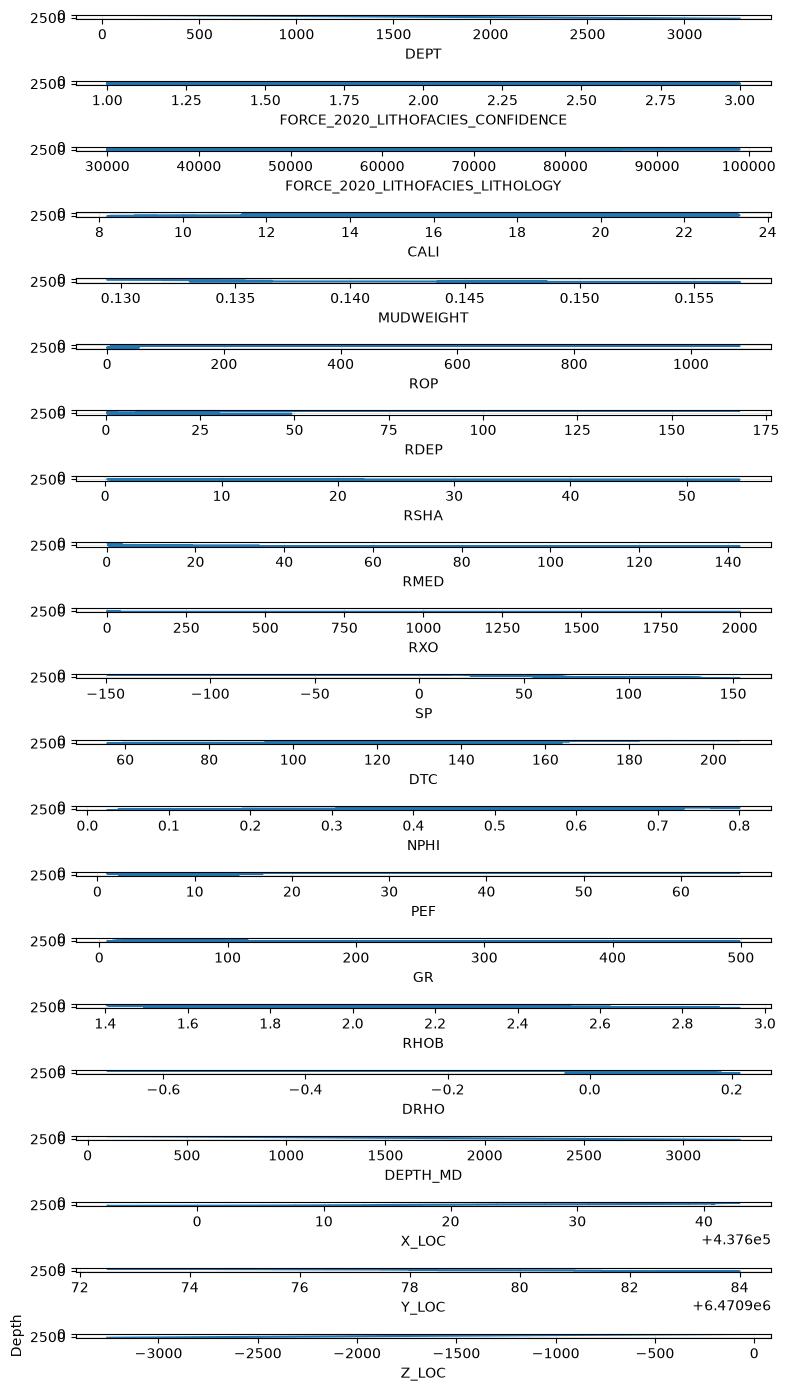

In [53]:
numeric_columns = df.select_dtypes(include=np.number).columns

fig, axes = plt.subplots(
    nrows=len(numeric_columns),
    ncols=1,
    figsize=(8, 14),
    sharey=True
)

if len(numeric_columns) == 1:
    axes = [axes]

for ax, column in zip(axes, numeric_columns):
    ax.plot(df[column], depth)
    ax.set_xlabel(column)
    ax.grid(True, alpha=0.3)

axes[-1].set_ylabel("Depth")
axes[-1].invert_yaxis()

plt.tight_layout()
plt.show()

In [55]:
# ============================================
# Dataset-wide well inventory
# ============================================

well_records = []
failed_wells = []

for path in las_files:
    try:
        # Read LAS file
        las_i = lasio.read(path)

        # Convert to DataFrame
        df_i = las_i.df().reset_index()

        # First column is expected to be depth
        depth_col_i = df_i.columns[0]

        # Convert depth to numeric for safe analysis
        depth_i = pd.to_numeric(df_i[depth_col_i], errors="coerce").dropna()

        # Calculate sampling intervals
        depth_diff_i = depth_i.diff().dropna()

        # Curve names
        curve_names = [curve.mnemonic for curve in las_i.curves]

        # Store information about this well
        well_records.append({
            "well_name": path.stem,
            "file_name": path.name,
            "n_samples": len(df_i),
            "depth_min": depth_i.min(),
            "depth_max": depth_i.max(),
            "median_step": depth_diff_i.median(),
            "mean_step": depth_diff_i.mean(),
            "n_curves": len(curve_names),
            "curves": ", ".join(curve_names)
        })

    except Exception as e:
        failed_wells.append({
            "file_name": path.name,
            "error": str(e)
        })


# Create inventory DataFrame
well_inventory = pd.DataFrame(well_records)

# Display basic information
print("Number of wells successfully inspected:", len(well_inventory))
print("Number of wells that failed:", len(failed_wells))

# display(well_inventory.head(10))
display(well_inventory)

Number of wells successfully inspected: 118
Number of wells that failed: 0


,well_name,file_name,n_samples,depth_min,depth_max,median_step,mean_step,n_curves,curves
0,15_9-13,15_9-13.las,21441,25.000000,3283.880000,0.152,0.152,21,"DEPT, FORCE_2020_LITHOFACIES_CONFIDENCE, FORCE..."
1,15_9-14,15_9-14.las,22875,98.804001,3575.652001,0.152,0.152,21,"DEPT, FORCE_2020_LITHOFACIES_CONFIDENCE, FORCE..."
2,15_9-15,15_9-15.las,20954,25.000000,3209.856000,0.152,0.152,23,"DEPT, FORCE_2020_LITHOFACIES_CONFIDENCE, FORCE..."
3,15_9-17,15_9-17.las,19879,102.613998,3124.069998,0.152,0.152,22,"DEPT, FORCE_2020_LITHOFACIES_CONFIDENCE, FORCE..."
4,15_9-23,15_9-23.las,20494,110.000000,3224.936000,0.152,0.152,21,"DEPT, FORCE_2020_LITHOFACIES_CONFIDENCE, FORCE..."
...,...,...,...,...,...,...,...,...,...
113,35_9-7,35_9-7.las,17166,397.050800,3006.130800,0.152,0.152,21,"DEPT, FORCE_2020_LITHOFACIES_CONFIDENCE, FORCE..."
114,35_9-8,35_9-8.las,18842,392.021600,3255.853600,0.152,0.152,21,"DEPT, FORCE_2020_LITHOFACIES_CONFIDENCE, FORCE..."
115,36_7-3,36_7-3.las,16950,373.000000,2949.248000,0.152,0.152,17,"DEPT, FORCE_2020_LITHOFACIES_CONFIDENCE, FORCE..."
116,7_1-1,7_1-1.las,17982,82.600800,2815.712800,0.152,0.152,21,"DEPT, FORCE_2020_LITHOFACIES_CONFIDENCE, FORCE..."


In [ ]:
# ============================================
# Save inventory to CSV
# ============================================
# output_folder = "./visualization_result"
# output_file = "All wells.csv"

# Create output folder if it doesn't exist
# os.makedirs(output_folder, exist_ok=True)

# Define full file path
# full_path = os.path.join(output_folder, output_file)

# Save well_inventory DataFrame to CSV
# well_inventory.to_csv(full_path, index=False)

# print(f"Saved successfully to: {full_path}")

Saved successfully to: ./visualization_result/All wells.csv


In [58]:
# ============================================
# Dataset-wide curve inventory
# ============================================

curve_presence = {}

for path in las_files:
    las_i = lasio.read(path)

    curve_names = [curve.mnemonic for curve in las_i.curves]

    curve_presence[path.stem] = set(curve_names)


# All unique curves across the complete dataset
all_curves = sorted(
    set().union(*curve_presence.values())
)

print("Total unique curves across all wells:", len(all_curves))
print("\nAll unique curves:")
for curve in all_curves:
    print(curve)

Total unique curves across all wells: 27

All unique curves:
BS
CALI
DCAL
DEPT
DEPTH_MD
DRHO
DTC
DTS
FORCE_2020_LITHOFACIES_CONFIDENCE
FORCE_2020_LITHOFACIES_LITHOLOGY
GR
MUDWEIGHT
NPHI
PEF
RDEP
RHOB
RMED
RMIC
ROP
ROPA
RSHA
RXO
SGR
SP
X_LOC
Y_LOC
Z_LOC


In [59]:
# ============================================
# Curve availability across wells
# ============================================

curve_availability = pd.DataFrame(
    False,
    index=sorted(curve_presence.keys()),
    columns=all_curves
)

for well_name, curves in curve_presence.items():
    for curve in curves:
        curve_availability.loc[well_name, curve] = True


# Number and percentage of wells containing each curve
curve_summary = pd.DataFrame({
    "n_wells": curve_availability.sum(axis=0),
    "percentage_wells": curve_availability.mean(axis=0) * 100
})

curve_summary = curve_summary.sort_values(
    "n_wells",
    ascending=False
)

display(curve_summary)

,n_wells,percentage_wells
Z_LOC,118,100.000000
RHOB,118,100.000000
Y_LOC,118,100.000000
DEPT,118,100.000000
DEPTH_MD,118,100.000000
DTC,118,100.000000
X_LOC,118,100.000000
FORCE_2020_LITHOFACIES_CONFIDENCE,118,100.000000
FORCE_2020_LITHOFACIES_LITHOLOGY,118,100.000000
GR,118,100.000000


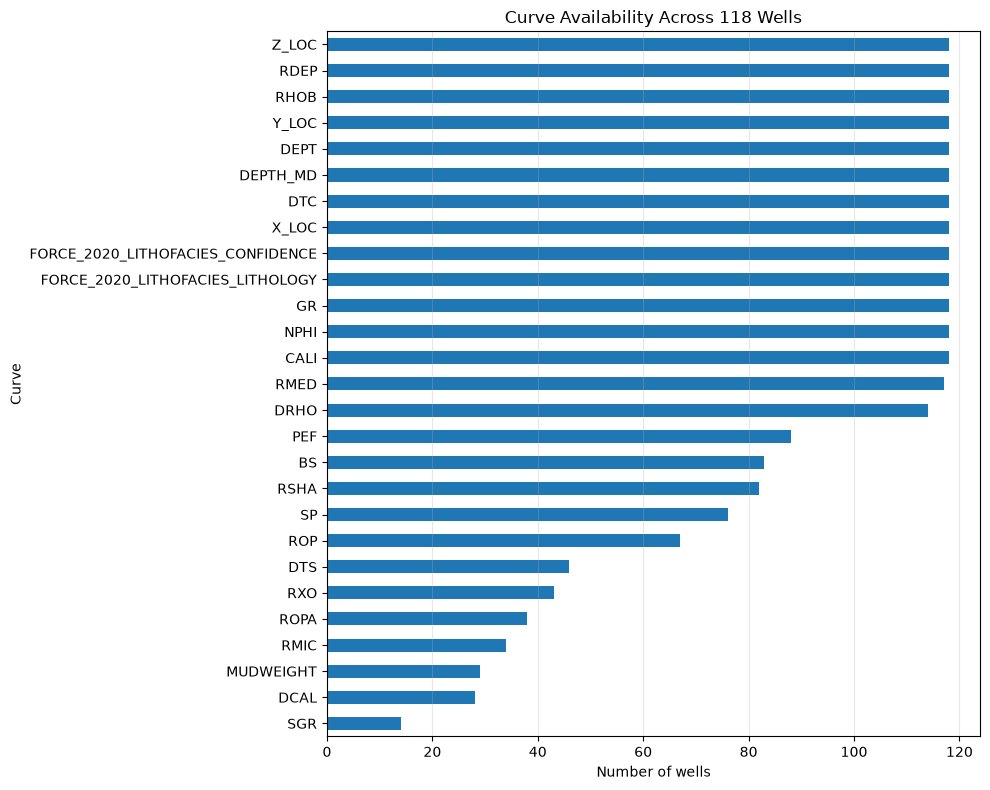

In [60]:
# ============================================
# Curve availability visualization
# ============================================

plt.figure(figsize=(10, 8))

curve_summary["n_wells"].sort_values().plot(
    kind="barh"
)

plt.xlabel("Number of wells")
plt.ylabel("Curve")
plt.title("Curve Availability Across 118 Wells")
plt.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.show()

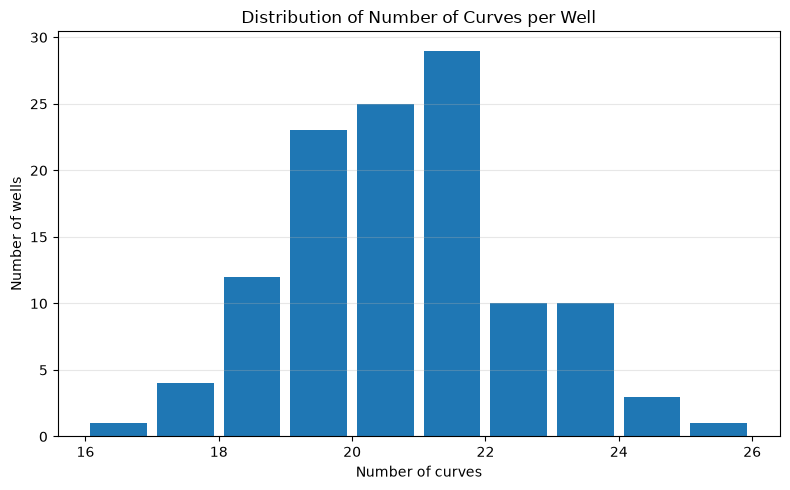

In [62]:
# ============================================
# Number of curves available per well
# ============================================

plt.figure(figsize=(8, 5))

well_inventory["n_curves"].plot(
    kind="hist",
    bins=range(
        int(well_inventory["n_curves"].min()),
        int(well_inventory["n_curves"].max()) + 2
    ),
    rwidth=0.85
)

plt.xlabel("Number of curves")
plt.ylabel("Number of wells")
plt.title("Distribution of Number of Curves per Well")
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

In [63]:
print("Minimum curves in a well:", well_inventory["n_curves"].min())
print("Maximum curves in a well:", well_inventory["n_curves"].max())
print("Median curves per well:", well_inventory["n_curves"].median())
print("Mean curves per well:", well_inventory["n_curves"].mean())

Minimum curves in a well: 16
Maximum curves in a well: 25
Median curves per well: 20.0
Mean curves per well: 20.279661016949152


In [64]:
# ============================================
# Sampling interval distribution
# ============================================

display(
    well_inventory[
        ["well_name", "median_step", "mean_step"]
    ].sort_values("median_step")
)

,well_name,median_step,mean_step
0,15_9-13,0.152,0.152
85,34_5-1 A,0.152,0.152
84,34_4-10 R,0.152,0.152
83,34_3-3 A,0.152,0.152
82,34_3-2 S,0.152,0.152
...,...,...,...
33,25_3-1,0.152,0.152
32,25_2-7,0.152,0.152
31,25_2-14,0.152,0.152
43,25_8-7,0.152,0.152


In [65]:
print("Unique median sampling intervals:")
print(
    well_inventory["median_step"]
    .round(6)
    .value_counts()
    .sort_index()
)

Unique median sampling intervals:
median_step
0.152    118
Name: count, dtype: int64


In [66]:
# ============================================
# Check for unusual depth intervals
# ============================================

depth_gap_records = []

for path in las_files:
    las_i = lasio.read(path)
    df_i = las_i.df().reset_index()

    depth_col_i = df_i.columns[0]
    depth_i = pd.to_numeric(
        df_i[depth_col_i],
        errors="coerce"
    ).dropna()

    depth_diff_i = depth_i.diff().dropna()

    depth_gap_records.append({
        "well_name": path.stem,
        "min_step": depth_diff_i.min(),
        "max_step": depth_diff_i.max(),
        "median_step": depth_diff_i.median(),
        "n_nonstandard_steps": (
            np.abs(depth_diff_i - 0.152) > 1e-6
        ).sum()
    })

depth_gap_summary = pd.DataFrame(depth_gap_records)

display(
    depth_gap_summary.sort_values(
        "n_nonstandard_steps",
        ascending=False
    ).head(20)
)

,well_name,min_step,max_step,median_step,n_nonstandard_steps
0,15_9-13,0.152,0.152,0.152,0
74,34_10-21,0.152,0.152,0.152,0
86,34_5-1 S,0.152,0.152,0.152,0
85,34_5-1 A,0.152,0.152,0.152,0
84,34_4-10 R,0.152,0.152,0.152,0
83,34_3-3 A,0.152,0.152,0.152,0
82,34_3-2 S,0.152,0.152,0.152,0
81,34_3-1 A,0.152,0.152,0.152,0
80,34_2-4,0.152,0.152,0.152,0
79,34_12-1,0.152,0.152,0.152,0


In [68]:
print(
    "Wells with at least one non-standard depth interval:",
    (depth_gap_summary["n_nonstandard_steps"] > 0).sum()
)

print(
    "Maximum number of non-standard intervals in one well:",
    depth_gap_summary["n_nonstandard_steps"].max()
)

Wells with at least one non-standard depth interval: 0
Maximum number of non-standard intervals in one well: 0


In [69]:
# ============================================
# Dataset-wide lithology inventory
# ============================================

LITHOLOGY_CURVE = "FORCE_2020_LITHOFACIES_LITHOLOGY"

lithology_records = []

for path in las_files:
    las_i = lasio.read(path)
    df_i = las_i.df().reset_index()

    if LITHOLOGY_CURVE not in df_i.columns:
        print(f"Warning: {LITHOLOGY_CURVE} not found in {path.name}")
        continue

    lithology = pd.to_numeric(
        df_i[LITHOLOGY_CURVE],
        errors="coerce"
    )

    counts = lithology.value_counts(dropna=True)

    for lithology_code, count in counts.items():
        lithology_records.append({
            "well_name": path.stem,
            "lithology_code": lithology_code,
            "n_samples": count
        })

lithology_by_well = pd.DataFrame(lithology_records)

display(lithology_by_well.head(20))

,well_name,lithology_code,n_samples
0,15_9-13,65000.0,12547
1,15_9-13,30000.0,2937
2,15_9-13,70000.0,1418
3,15_9-13,65030.0,708
4,15_9-13,80000.0,429
5,15_9-13,99000.0,173
6,15_9-13,74000.0,41
7,15_9-13,86000.0,17
8,15_9-14,65030.0,6468
9,15_9-14,65000.0,6178


In [70]:
# ============================================
# Overall lithology distribution
# ============================================

lithology_distribution = (
    lithology_by_well
    .groupby("lithology_code")["n_samples"]
    .sum()
    .sort_values(ascending=False)
)

lithology_distribution_df = pd.DataFrame({
    "n_samples": lithology_distribution,
    "percentage": (
        lithology_distribution
        / lithology_distribution.sum()
        * 100
    )
})

display(lithology_distribution_df)

,n_samples,percentage
lithology_code,,
65000.0,877043,61.272420
30000.0,207704,14.510721
65030.0,180820,12.632538
70000.0,69498,4.855304
80000.0,41038,2.867017
99000.0,17431,1.217773
88000.0,14712,1.027817
70032.0,14043,0.981079
90000.0,4754,0.332126


In [71]:
# ============================================
# Lithology code → lithology name
# ============================================

lithology_mapping = {
    30000: "Sandstone",
    65000: "Shale",
    65030: "Sandstone/Shale",
    70000: "Limestone",
    70032: "Chalk",
    74000: "Dolomite",
    80000: "Marl",
    86000: "Anhydrite",
    88000: "Halite",
    90000: "Coal",
    93000: "Basement",
    99000: "Tuff"
}

lithology_distribution_named = lithology_distribution_df.copy()

lithology_distribution_named["lithology_name"] = (
    lithology_distribution_named.index
    .astype(int)
    .map(lithology_mapping)
)

lithology_distribution_named = (
    lithology_distribution_named
    .reset_index()
    .rename(columns={"index": "lithology_code"})
)

display(lithology_distribution_named)

,lithology_code,n_samples,percentage,lithology_name
0,65000.0,877043,61.272420,Shale
1,30000.0,207704,14.510721,Sandstone
2,65030.0,180820,12.632538,Sandstone/Shale
3,70000.0,69498,4.855304,Limestone
4,80000.0,41038,2.867017,Marl
5,99000.0,17431,1.217773,Tuff
6,88000.0,14712,1.027817,Halite
7,70032.0,14043,0.981079,Chalk
8,90000.0,4754,0.332126,Coal
9,74000.0,2391,0.167041,Dolomite


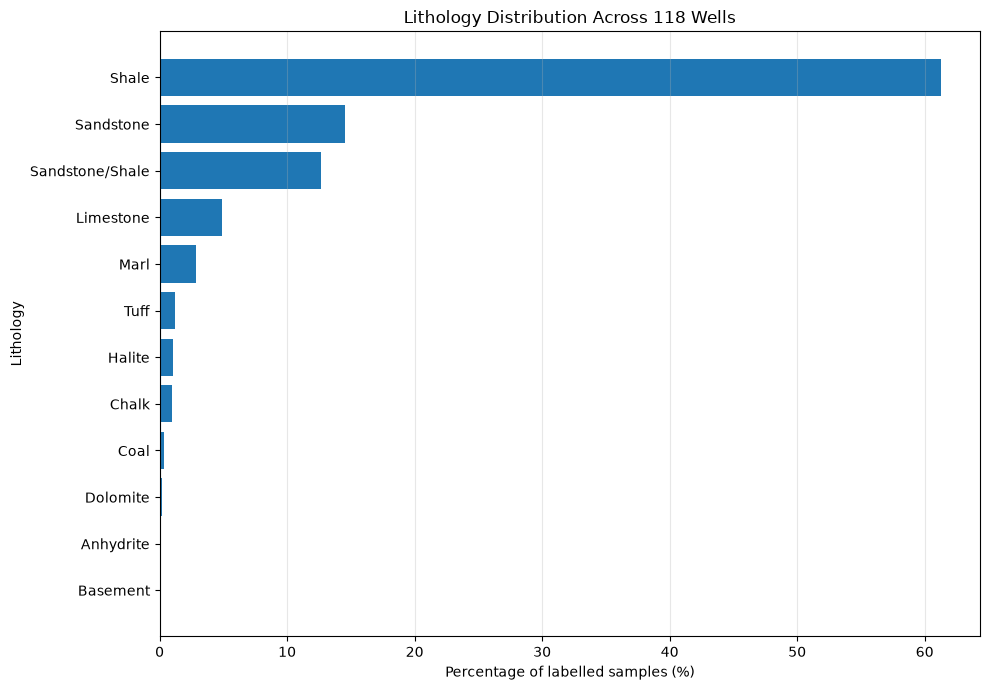

In [72]:
# ============================================
# Lithology distribution with names
# ============================================

plot_data = (
    lithology_distribution_named
    .sort_values("percentage")
)

plt.figure(figsize=(10, 7))

plt.barh(
    plot_data["lithology_name"],
    plot_data["percentage"]
)

plt.xlabel("Percentage of labelled samples (%)")
plt.ylabel("Lithology")
plt.title("Lithology Distribution Across 118 Wells")

plt.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.show()

In [73]:
# ============================================
# Number of wells containing each lithology
# ============================================

lithology_well_presence = (
    lithology_by_well
    .groupby("lithology_code")["well_name"]
    .nunique()
    .sort_values(ascending=False)
)

lithology_well_presence_df = pd.DataFrame({
    "n_wells": lithology_well_presence,
    "percentage_wells": (
        lithology_well_presence / len(las_files) * 100
    )
})

lithology_well_presence_df["lithology_name"] = (
    lithology_well_presence_df.index
    .astype(int)
    .map(lithology_mapping)
)

display(lithology_well_presence_df)

,n_wells,percentage_wells,lithology_name
lithology_code,,,
30000.0,118,100.000000,Sandstone
65000.0,118,100.000000,Shale
65030.0,117,99.152542,Sandstone/Shale
70000.0,114,96.610169,Limestone
80000.0,92,77.966102,Marl
99000.0,67,56.779661,Tuff
90000.0,63,53.389831,Coal
74000.0,47,39.830508,Dolomite
70032.0,15,12.711864,Chalk


In [74]:
 # ============================================
# Lithology presence across wells
# ============================================

lithology_presence_matrix = (
    lithology_by_well
    .pivot_table(
        index="well_name",
        columns="lithology_code",
        values="n_samples",
        aggfunc="sum",
        fill_value=0
    )
)

# Convert counts to presence/absence
lithology_presence_binary = (
    lithology_presence_matrix > 0
)

# Use lithology names for columns
lithology_presence_binary.columns = [
    lithology_mapping.get(int(code), str(code))
    for code in lithology_presence_binary.columns
]

display(lithology_presence_binary.head())

,Sandstone,Shale,Sandstone/Shale,Limestone,Chalk,Dolomite,Marl,Anhydrite,Halite,Coal,Basement,Tuff
well_name,,,,,,,,,,,,
15_9-13,True,True,True,True,False,True,True,True,False,False,False,True
15_9-14,True,True,True,True,True,False,True,False,False,True,False,True
15_9-15,True,True,True,True,True,False,True,False,False,False,False,True
15_9-17,True,True,True,True,False,True,True,False,False,False,False,True
15_9-23,True,True,True,True,True,False,True,False,False,True,False,True


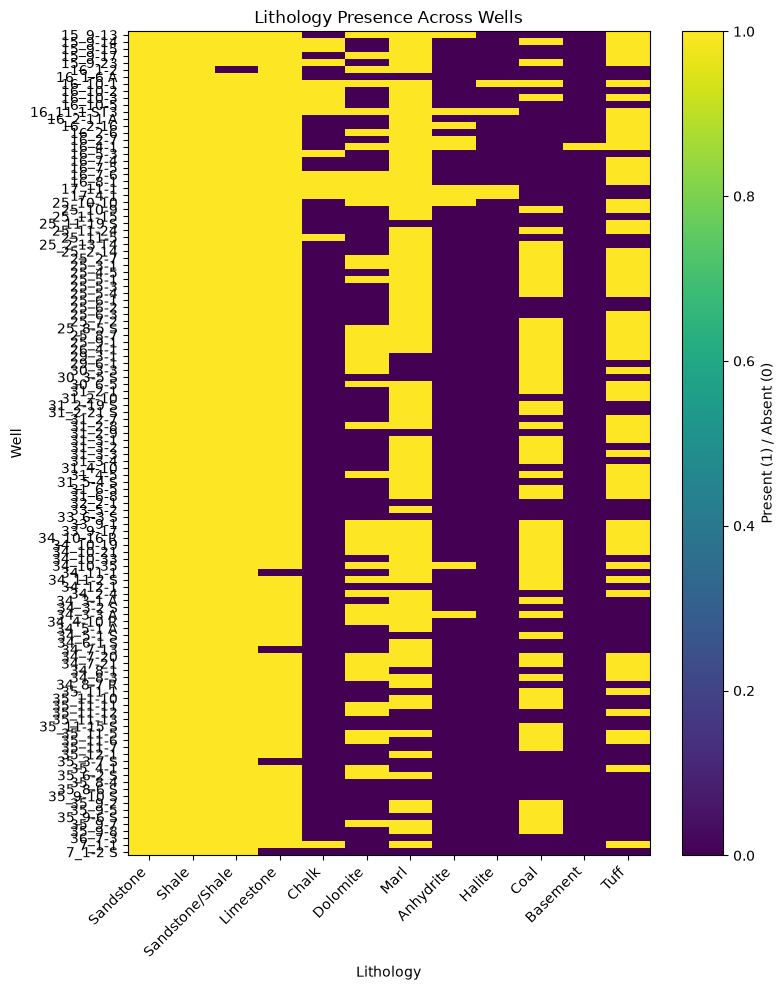

In [78]:
# ============================================
# Lithology presence/absence heatmap
# ============================================

plt.figure(figsize=(8, 10))

plt.imshow(
    lithology_presence_binary.values,
    aspect="auto",
    interpolation="nearest"
)

plt.xticks(
    range(len(lithology_presence_binary.columns)),
    lithology_presence_binary.columns,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(lithology_presence_binary.index)),
    lithology_presence_binary.index
)

plt.xlabel("Lithology")
plt.ylabel("Well")
plt.title("Lithology Presence Across Wells")

plt.colorbar(
    label="Present (1) / Absent (0)"
)

plt.tight_layout()
plt.show()

In [80]:
# ============================================
# Dataset-wide missing-value overview
# ============================================

missing_records = []

for path in las_files:
    las_i = lasio.read(path)
    df_i = las_i.df().reset_index()

    for column in df_i.columns:
        missing_count = df_i[column].isna().sum()
        total_count = len(df_i)

        missing_records.append({
            "well_name": path.stem,
            "curve": column,
            "n_samples": total_count,
            "n_missing": missing_count,
            "missing_percentage": (
                missing_count / total_count * 100
            )
        })

missing_summary = pd.DataFrame(missing_records)

display(missing_summary.head(20))

,well_name,curve,n_samples,n_missing,missing_percentage
0,15_9-13,DEPT,21441,0,0.000000
1,15_9-13,FORCE_2020_LITHOFACIES_CONFIDENCE,21441,3164,14.756774
2,15_9-13,FORCE_2020_LITHOFACIES_LITHOLOGY,21441,3171,14.789422
3,15_9-13,CALI,21441,3096,14.439625
4,15_9-13,MUDWEIGHT,21441,3921,18.287393
5,15_9-13,ROP,21441,1144,5.335572
6,15_9-13,RDEP,21441,485,2.262021
7,15_9-13,RSHA,21441,19818,92.430390
8,15_9-13,RMED,21441,484,2.257357
9,15_9-13,RXO,21441,19814,92.411735


In [81]:
# ============================================
# Missing values aggregated by curve
# ============================================

curve_missing_summary = (
    missing_summary
    .groupby("curve")
    .agg(
        wells=("well_name", "nunique"),
        total_samples=("n_samples", "sum"),
        total_missing=("n_missing", "sum")
    )
)

curve_missing_summary["missing_percentage"] = (
    curve_missing_summary["total_missing"]
    / curve_missing_summary["total_samples"]
    * 100
)

curve_missing_summary = (
    curve_missing_summary
    .sort_values("missing_percentage", ascending=False)
)

display(curve_missing_summary)

,wells,total_samples,total_missing,missing_percentage
curve,,,,
SGR,14,285020,212857,74.681426
RMIC,34,634460,396083,62.428364
DTS,46,936453,547632,58.479390
NPHI,118,2337639,1304036,55.784319
RXO,43,840619,454412,54.056832
PEF,88,1802557,878417,48.731718
RSHA,82,1589966,721506,45.378706
DRHO,114,2252958,928048,41.192423
RHOB,118,2337639,941122,40.259510


# Dataset Visualization — Main Observations

The FORCE 2020 dataset contains 118 LAS wells.

## Dataset structure

- 118/118 LAS files were successfully loaded.
- Well sample counts vary between wells.
- The depth sampling interval is consistently 0.152 m.
- No non-standard depth intervals were detected in the inspected wells.

## Curve availability

Several curves are available across all or nearly all wells, including:

- GR
- RDEP
- RMED
- DTC
- RHOB
- NPHI
- CALI
- DRHO

However, curve availability across wells does not imply that the curve is complete
within each well.

## Lithology

The dataset contains 12 lithology classes.

The labelled samples are strongly imbalanced. Shale (65000) is the dominant class,
while Basement (93000) is extremely rare.

Lithology coverage also varies substantially between wells. Some classes occur in
nearly every well, while others occur in only a few wells.

## Missing values

The complete dataset contains 2,337,639 depth samples.

The lithology target contains 906,256 missing values, leaving 1,431,383 labelled
samples.

Several input curves also contain substantial missing values. Therefore, feature
selection and missing-value treatment must be investigated systematically rather
than decided only from curve availability.

## Important modeling implication

The observations suggest that train/validation/test splitting should be considered
at the well level rather than by randomly splitting individual depth samples, in
order to reduce information leakage between wells.

No cleaning, imputation, resampling, or feature selection is performed in this
notebook. Those decisions are investigated in the data-quality and preprocessing
stages.